## **Spectroscopic IROS Reconstruction**

In [1]:
from pathlib import Path

from bloodmoon.mask import CodedMaskCamera, codedmask
from bloodmoon.io import simulation_files
import darksun as ds

ds.show.set_figures_darkbkg()

In [2]:
BASE_PATH: str = "/mnt/dbb8f47e-da06-47bf-8ef5-038092af70f7/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data"
SIM_PATH: str = f"{BASE_PATH}/Simulations"
OUT_PATH: str = f"{BASE_PATH}/Outputs"

# BASE_PATH: str = "/mnt/d/PhD_AASS/Coding/Images_fits"
# SIM_PATH = OUT_PATH = BASE_PATH

In [3]:
# MASK_FITS: str = "mask_NTHT_20260129_CORRECTED.fits"
MASK_FITS: str = "mask_NTHT_20250725.fits"
UPS_X: int = 2
UPS_Y: int = 1

wfm: CodedMaskCamera = codedmask(f"{SIM_PATH}/{MASK_FITS}", UPS_X, UPS_Y)

In [4]:
# SKYFIELD: str = "IROSDummy"
# DATA_FITS: str = "iros_benchmark_2-50keV_mask_050_1040x17_1ks"
SKYFIELD: str = "GalacticCentre"
DATA_FITS: str = "galctr_rxte-sax_mask_050_1040x17_2-50keV_1ks"

ID_CAMERA_A: str = "cam1a"
DATASET: str = "reconstructed"

filepaths: dict[str, dict[str, Path]] = simulation_files(f"{SIM_PATH}/{SKYFIELD}/{DATA_FITS}")

In [5]:
from typing import Any

import numpy as np
from numpy.typing import NDArray
from astropy.io.fits import FITS_rec
from tqdm import tqdm

from bloodmoon.types import CoordEquatorial
from darksun.data import Log
from darksun.benchmarking import source_catalogue_data
from darksun.data import DataLoader, CatalogueLoader

from IROSrec.iros.optim import iros_singleCAM
from IROSrec.iros.procedure import run_IROS, get_sources_database

In [6]:
# - data gathering from specific direction
#   NOTE: Filtering the whole photons list by specific incoming direction associated with a source
#         is just a way to reduce the computational cost of data handling operations.
#         Since we are dealing with a WM sim, we know the actual photons directions. In a real
#         obs this info is lost in the encoding phase (hence, we can only filter for energy).
#   NOTE: If the spectroscopic analysis is performed AFTER a first IROS reconstruction, the sources
#         coords in the camera local-frame are known, and can be utilised in the sky image to select
#         subsections of the skymap for the spectroscopic analysis (e.g., as an external trigger).

def get_source_coords(sourceID: str, catalogue: CatalogueLoader) -> CoordEquatorial:
    """Extracts the source RA/Dec coords from catalogue."""
    data = source_catalogue_data(sourceID, catalogue.DLdata)
    return CoordEquatorial(data['RA'], data['DEC'])

def select_target_srcs(
    photons: FITS_rec,
    srcIDs: str | tuple[str, ...],
    catalogue: CatalogueLoader,
) -> FITS_rec:
    """Filters the input photon list for the given sources equatorial coords."""
    srcIDs_ = (srcIDs,) if isinstance(srcIDs, str) else srcIDs
    coords = tuple(get_source_coords(src, catalogue) for src in srcIDs_)
    phs = ds.select_source_photons(coords, photons, False)
    return phs

In [7]:
# - energy bands scheduler and filtering

type EnergyRange = tuple[float, float]
type EnergySchedule = dict[int, EnergyRange]

def eband_schedule(emin: float, emax: float, ebins: float) -> EnergySchedule:
    """Defines a linear schedule for the energy bands to analyse."""
    if not (emax > emin) or (emax - emin < ebins):
        raise ValueError('Invalid energy band boundary values.')
     
    nruns = int((emax - emin) / ebins)
    schedule = {run: (float(emin), float(emin + run * ebins)) for run in range(1, nruns + 1)}
    return schedule

def eband_custom_schedule(e_start: float, ebins: float | tuple[float, ...]) -> EnergySchedule:
    """Defines a custom energy bands schedule with given `ebins` size, from `e_start`."""
    ebins_ = (ebins,) if isinstance(ebins, (int, float)) else ebins
    schedule = {
        (run + 1): (float(e_start), float(e_start + cumbin))
        for run, cumbin in enumerate(np.cumsum(ebins_))
    }
    return schedule

def select_eband_phs(photons: FITS_rec, eband: EnergyRange) -> FITS_rec:
    """Filters the input photon list in the given energy band."""
    E_min, E_max = eband
    return ds.filter_data(photons, E_min=E_min, E_max=E_max, coords=None)

In [ ]:
from bloodmoon.mask import count, variance
from darksun.handle import save_pickle, load_pickle

# - define operations for single energy band IROS run

def perform_IROS(
    camera: CodedMaskCamera,
    detector: NDArray,
    max_iterations: int,
    camID: str | None = None,
    **iros_kwargs: Any,
) -> Log:
    """Runs the IROS procedure and stores optimised sources params."""
    loop = iros_singleCAM(camera, detector, max_iterations, **iros_kwargs)
    log, _ = run_IROS(camera, loop, camID)
    return log


def run_IROS_spectr_rec(
    camera: CodedMaskCamera,
    sdl: DataLoader,
    srcIDs: str | tuple[str, ...],
    schedule: EnergySchedule,
    catalogue: CatalogueLoader,
    vignetting: bool = True,
    screening: bool = True,
    save_to: str | None = None,
    **iros_kwargs: Any,
) -> dict[EnergyRange, Log]:
    """
    Performs the spectroscopic IROS reconstruction in the specified energy bands.

    NOTE:
        * The BKG is filtered out (if CXB phs are flagged, they can be kept
          in the data by adding the flag ID to the `srcIDs` sequence).
    """
    srcIDs_ = (srcIDs,) if isinstance(srcIDs, str) else srcIDs
    out: dict[EnergyRange, Log] = {}

    # filter for sources
    photons = select_target_srcs(sdl.DLdata, srcIDs_, catalogue)

    # run eband reconstr
    _det, _ = count(camera, sdl.DLdata)
    varmap = variance(camera, _det)
    max_iterations = 2 * len(srcIDs_)
    rec_loop = tqdm(list(schedule.items()))

    for runID, eband in rec_loop:
        rec_loop.set_description(f'Run {runID} | IROS reconstr - {eband} keV')
        phs = select_eband_phs(photons, eband)
        eband_detector, _ = count(camera, phs)
        log = perform_IROS(camera, eband_detector, max_iterations, varmap=varmap, **iros_kwargs)
        log = get_sources_database(camera, sdl, catalogue, log, vignetting, screening)
        out[eband] = log
    
    if save_to is not None: save_pickle(out, save_to)
    
    return out

In [9]:
sdlA = ds.get_data(filepaths[ID_CAMERA_A][DATASET])
catA = ds.get_catalogue(filepaths[ID_CAMERA_A]['sources'])

# schedule: EnergySchedule = eband_schedule(2.0, 10.0, 2.0)

ebins = [0.5] * 26
schedule: EnergySchedule = eband_custom_schedule(2.0, ebins)

print(schedule)

{1: (2.0, 2.5), 2: (2.0, 3.0), 3: (2.0, 3.5), 4: (2.0, 4.0), 5: (2.0, 4.5), 6: (2.0, 5.0), 7: (2.0, 5.5), 8: (2.0, 6.0), 9: (2.0, 6.5), 10: (2.0, 7.0), 11: (2.0, 7.5), 12: (2.0, 8.0), 13: (2.0, 8.5), 14: (2.0, 9.0), 15: (2.0, 9.5), 16: (2.0, 10.0), 17: (2.0, 10.5), 18: (2.0, 11.0), 19: (2.0, 11.5), 20: (2.0, 12.0), 21: (2.0, 12.5), 22: (2.0, 13.0), 23: (2.0, 13.5), 24: (2.0, 14.0), 25: (2.0, 14.5), 26: (2.0, 15.0)}


In [10]:
OUT_RESULTS_PATH: str = '/mnt/dbb8f47e-da06-47bf-8ef5-038092af70f7/Edos_Magnificent_Manor/PhD_AASS/IROS_paper'
# OUT_RESULTS_PATH = "/mnt/d/PhD_AASS/Coding/Images_fits"

DATA_ID: str = 'out_IROS_data_test_2-15keV_1ks_SCOX-1.pickle'



srcIDs = (
    'scox1', #'gx5-1', 'gx349+2', 'gx17+2',
)

fp: Path = Path(f'{OUT_RESULTS_PATH}/{DATA_ID}')
if not fp.exists():
    out_logs = run_IROS_spectr_rec(
        camera=wfm,
        sdl=sdlA,
        srcIDs=srcIDs,
        schedule=schedule,
        catalogue=catA,
        save_to=fp,
    )
else:
    out_logs = load_pickle(fp)

## USING BULK MASK with 1.5 mm cover ##


Run 1 | IROS reconstr - (2.0, 2.5) keV:   0%|          | 0/26 [00:00<?, ?it/s]

# Looping around the FOV...



## Optimisation Results:
  * p[0]:
      - START.: 43.8750000
      - OPTIM.: 43.9096223 +/- 0.0002712
      - GAIN.: 0.079 %
  * p[1]:
      - START.: 78.0000000
      - OPTIM.: 78.1984723 +/- 0.0153392
      - GAIN.: 0.254 %
  * p[2]:
      - START.: 40045.6300454
      - OPTIM.: 39113.9675203 +/- 74.7179738
      - GAIN.: -2.327 %

## Fit Report:
  - func calls (also # of iters): 7
  - procedure msg: Both `ftol` and `xtol` termination conditions are satisfied.
  - success status 4: Convergence in orthogonality



IROS sky-reconstruction: 1it [00:06,  6.60s/it]
Run 2 | IROS reconstr - (2.0, 3.0) keV:   4%|▍         | 1/26 [00:06<02:49,  6.77s/it]

...

# Comparing with Catalogue...
# Successful comparison!
# Looping around the FOV...


IROS sky-reconstruction: 1it [00:05,  5.48s/it]


## Optimisation Results:
  * p[0]:
      - START.: 43.8750000
      - OPTIM.: 43.9148672 +/- 0.0000272
      - GAIN.: 0.091 %
  * p[1]:
      - START.: 78.0000000
      - OPTIM.: 78.0585340 +/- 0.0015821
      - GAIN.: 0.075 %
  * p[2]:
      - START.: 1040289.4184444
      - OPTIM.: 994373.8313910 +/- 193.0034282
      - GAIN.: -4.414 %

## Fit Report:
  - func calls (also # of iters): 7
  - procedure msg: `ftol` termination condition is satisfied.
  - success status 2: Convergence in parameter values


No candidates left...



Run 26 | IROS reconstr - (2.0, 15.0) keV: 100%|██████████| 26/26 [03:09<00:00,  7.29s/it]

# Comparing with Catalogue...
# Successful comparison!
# Saving data...
# Saving completed!


In [11]:
for runID, (eband, log) in enumerate(out_logs.items()):
    print(f'Run {runID + 1}, eband {eband} keV  |  Sources: {log.log['ID']} (brightest: {log.log['ID_brightest']})')

Run 1, eband (2.0, 2.5) keV  |  Sources: ['scox1'] (brightest: ['scox1'])
Run 2, eband (2.0, 3.0) keV  |  Sources: ['scox1'] (brightest: ['scox1'])
Run 3, eband (2.0, 3.5) keV  |  Sources: ['scox1'] (brightest: ['scox1'])
Run 4, eband (2.0, 4.0) keV  |  Sources: ['scox1', 'lemx-S1'] (brightest: ['scox1', 'lemx-S1'])
Run 5, eband (2.0, 4.5) keV  |  Sources: ['scox1', 'lemx-S1'] (brightest: ['scox1', 'lemx-S1'])
Run 6, eband (2.0, 5.0) keV  |  Sources: ['scox1', 'lemx-S1'] (brightest: ['scox1', 'lemx-S1'])
Run 7, eband (2.0, 5.5) keV  |  Sources: ['scox1'] (brightest: ['scox1'])
Run 8, eband (2.0, 6.0) keV  |  Sources: ['scox1'] (brightest: ['scox1'])
Run 9, eband (2.0, 6.5) keV  |  Sources: ['scox1'] (brightest: ['scox1'])
Run 10, eband (2.0, 7.0) keV  |  Sources: ['scox1'] (brightest: ['scox1'])
Run 11, eband (2.0, 7.5) keV  |  Sources: ['scox1'] (brightest: ['scox1'])
Run 12, eband (2.0, 8.0) keV  |  Sources: ['scox1'] (brightest: ['scox1'])
Run 13, eband (2.0, 8.5) keV  |  Sources: [

In [12]:
def compute_spectra(runs: dict[EnergyRange, Log]) -> tuple[NDArray, NDArray]:
    """
    Computes the sources spectra from IROS reconstruction by fluxes subtraction in cumulative ebands.
    Returns the energy bins and the sources spectra (per column, across runs).
    * TODO: insert check on logged data to match srcs to flxs vals across runs.
    """
    # NOTE: gather vals, we assume that flxs are coherent with respective srcs across runs
    ebands = np.array(list(runs.keys()))
    last_to_keep = min([len(log.log['ID']) for log in runs.values()])
    flxs = np.array([log.log['flux'][:last_to_keep] for log in runs.values()])
    # compute energy bins + reintroduce first ebin
    esteps = np.diff(ebands, axis=0)[:, -1]
    esteps = np.concat((np.diff(ebands[0]), esteps))
    ebins = np.concat(([ebands[0][0]], ebands[0][0] + np.cumsum(esteps)))
    # compute flxs eband-subtraction + reintroduce first ebin
    flx_cumsubtr = np.concat(([flxs[0]], np.diff(flxs, axis=0)))
    return ebins, flx_cumsubtr / esteps[:, None]

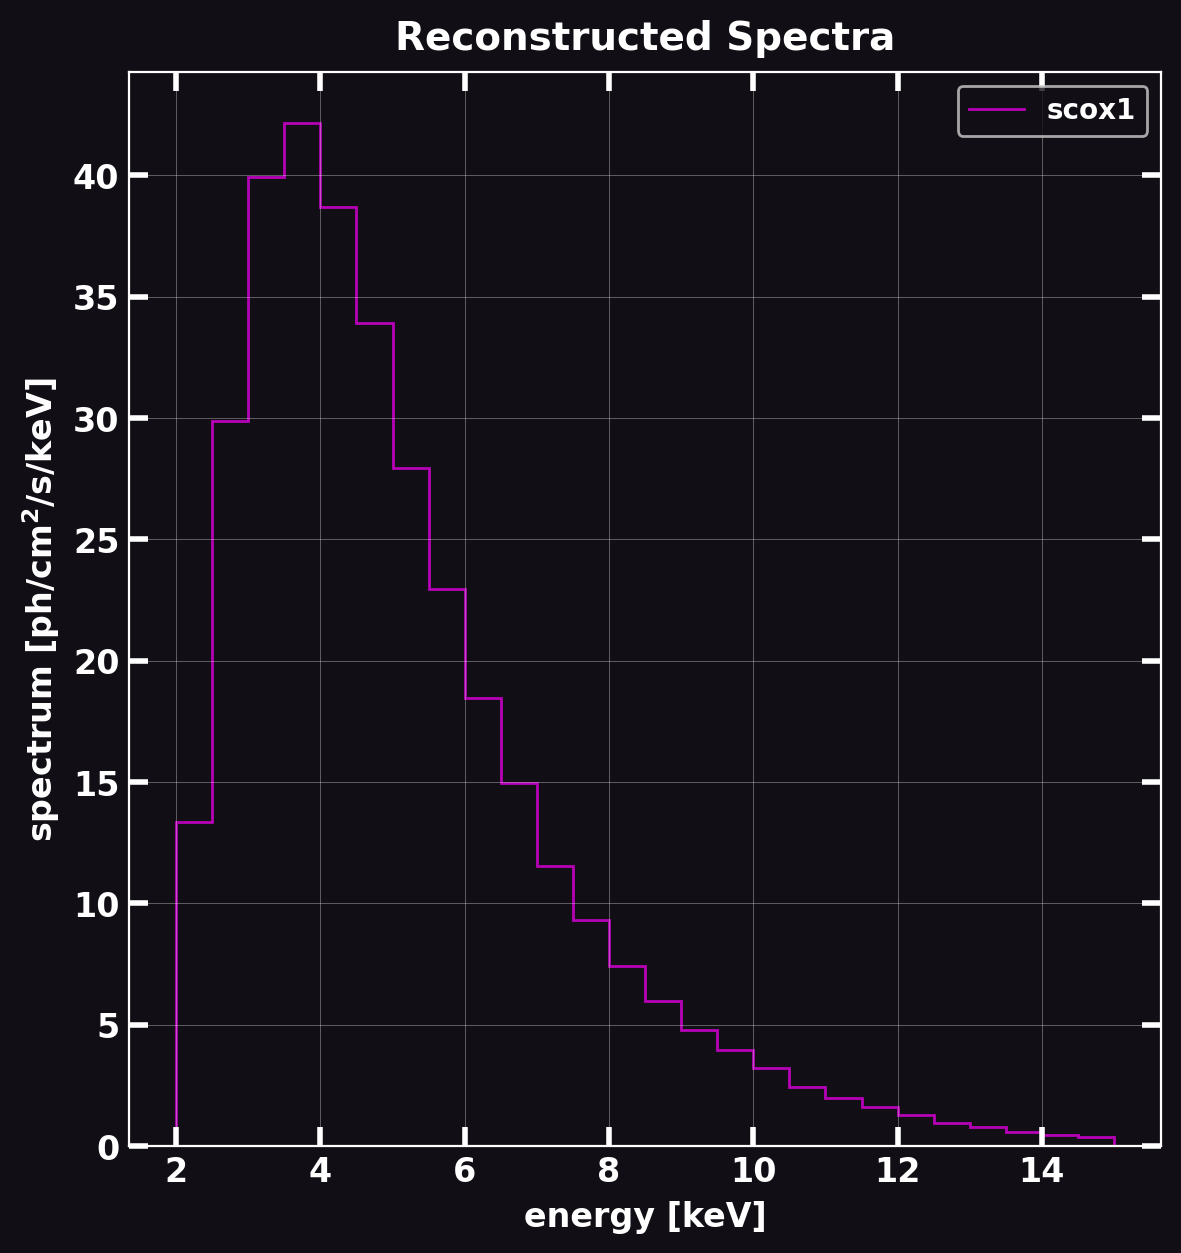

In [ ]:
ebins, spectra = compute_spectra(out_logs)

ds.plot(
    ds.map4plot(
        arrs=tuple(spectra[:, idx] for idx in range(spectra.shape[-1])),
        title='Reconstructed Spectra',
        x=ebins,
        xlabel='energy [keV]',
        ylabel='spectrum [ph/cm$^{2}$/s/keV]',
        labels=srcIDs,
        style='stairs',
        color='m',
        yscale='log',
    ),
    save_to=f'{OUT_RESULTS_PATH}/spectrs.png',
)

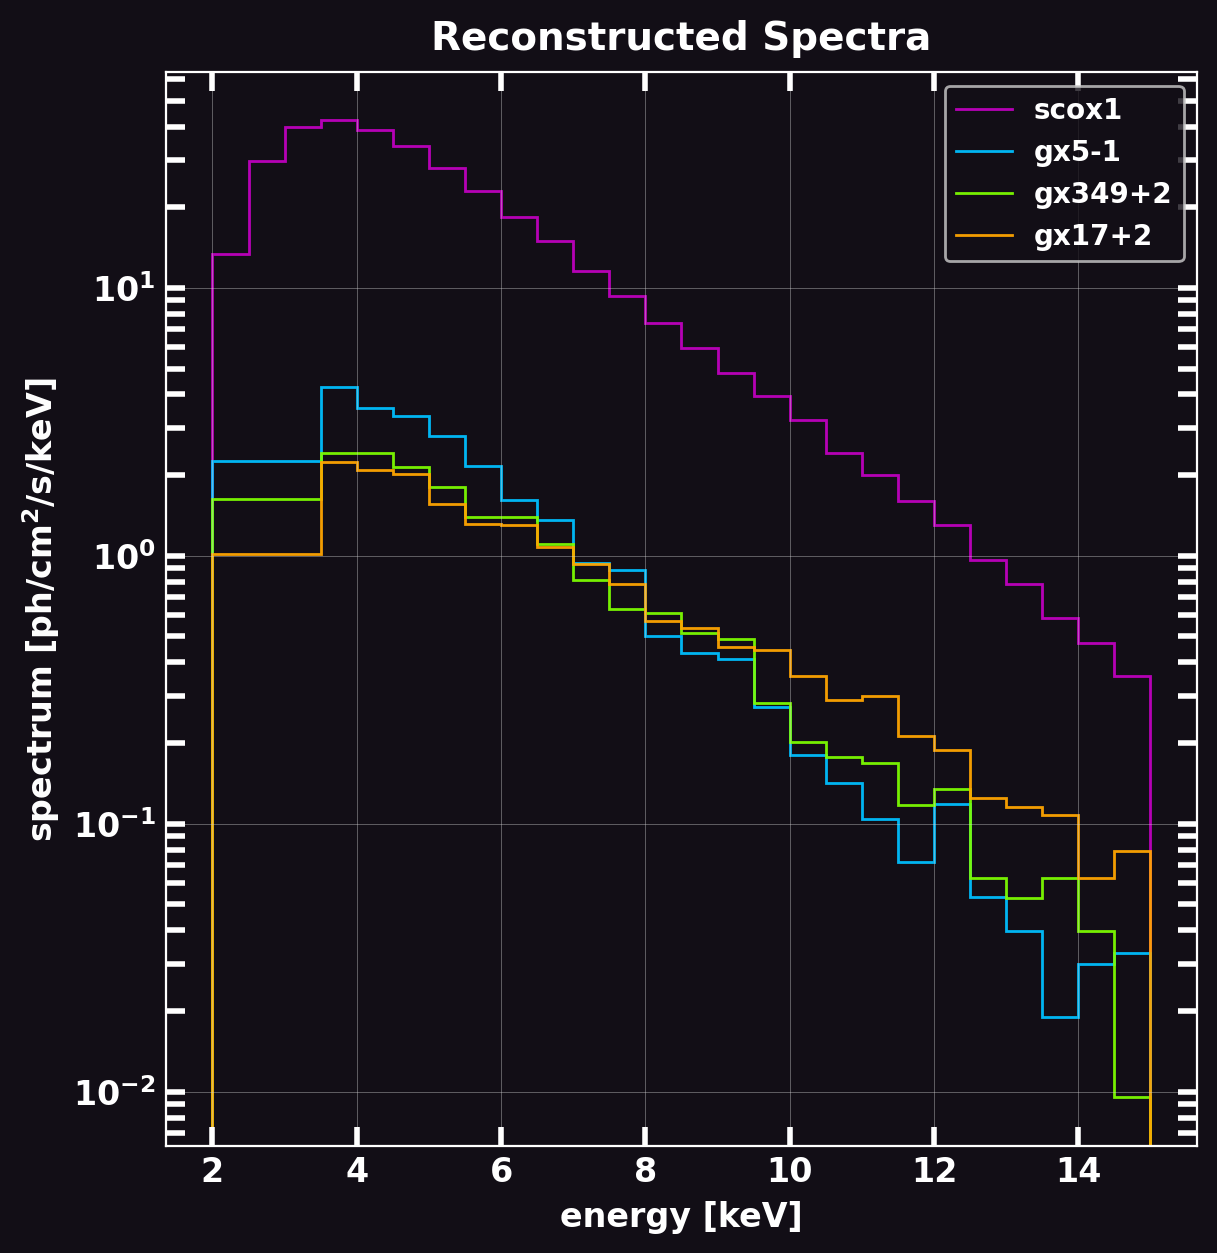

In [ ]:
# ebins, spectra = compute_spectra(out_logs)
# ebins_, spectra_ = compute_spectra({k: v for k, v in list(out_logs.items())[2:]})

# ds.plot(
#     ds.map4plot(
#         arrs=(
#             list(spectra[:, idx] for idx in range(spectra.shape[-1])) + \
#             list(spectra_[:, idx] for idx in range(1, spectra_.shape[-1]))
#         ),
#         title='Reconstructed Spectra',
#         x=[ebins] * spectra.shape[-1] + [ebins_] * (spectra_.shape[-1] - 1),
#         xlabel='energy [keV]',
#         ylabel='spectrum [ph/cm$^{2}$/s/keV]',
#         labels=srcIDs,
#         style='stairs',
#         color=('m', 'DeepSkyBlue', 'LawnGreen', 'Orange'),
#         yscale='log',
#     ),
#     save_to=f'{SAVE_DATA_TO}/spectrs.png',
# )

In [14]:
import numpy as np

a = np.array(['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i'])
b = np.array(['a', 'b', 'x', 'c', 'd', 'y', 'e', 'f', 'g'])

common, idx_a, idx_b = np.intersect1d(a, b, assume_unique=True, return_indices=True)


np.all(a[idx_a] == b[idx_b])

np.True_

In [ ]:
from bloodmoon.coords import equatorial2shift
from darksun.analyze import get_effective_area



def get_src_flx_from_data(
    camera: CodedMaskCamera,
    sdl: DataLoader,
    srcIDs: str | tuple[str, ...],
    schedule: EnergySchedule,
    catalogue: CatalogueLoader,
    vignetting: bool = True,
) -> dict[EnergyRange, Log]:
    """Computes the sources fluxes from collected data following the input energy schedule."""
    ...




def gather_src_spectr_from_data(
    camera: CodedMaskCamera,
    sdl: DataLoader,
    srcIDs: str | tuple[str, ...],
    schedule: EnergySchedule,
    catalogue: CatalogueLoader,
    vignetting: bool = True,
) -> dict[EnergyRange, Log]:
    """Gathers the given sources fluxes from collected data following the input energy schedule."""
    srcIDs_ = (srcIDs,) if isinstance(srcIDs, str) else srcIDs
    out: dict[EnergyRange, Log] = {}

    src_loop = tqdm(srcIDs_)
    for src in src_loop:
        src_loop.set_description(f'Gathering from {src.upper()}')
        flxs: list[float] = []
        photons = select_target_srcs(sdl.DLdata, src, catalogue)
        sx, sy = equatorial2shift(sdl, camera, *get_source_coords(src, catalogue))
        area_eff = get_effective_area(camera, sx, sy, vignetting)
        exposure = sdl.header['EXPOSURE']

        for eband in schedule.values():
            phs = select_eband_phs(photons, eband)
            eband_detector, _ = count(camera, phs)
            flxs.append(eband_detector.sum() / area_eff / exposure / float(np.diff(eband)[0]))
        
        out[src] = np.array(spectr)
    
    return out

In [17]:
true_spectr = gather_src_spectr_from_data(wfm, sdlA, srcIDs, schedule, catA)

Gathering from SCOX1: 100%|██████████| 1/1 [00:06<00:00,  6.46s/it]


IndexError: tuple index out of range

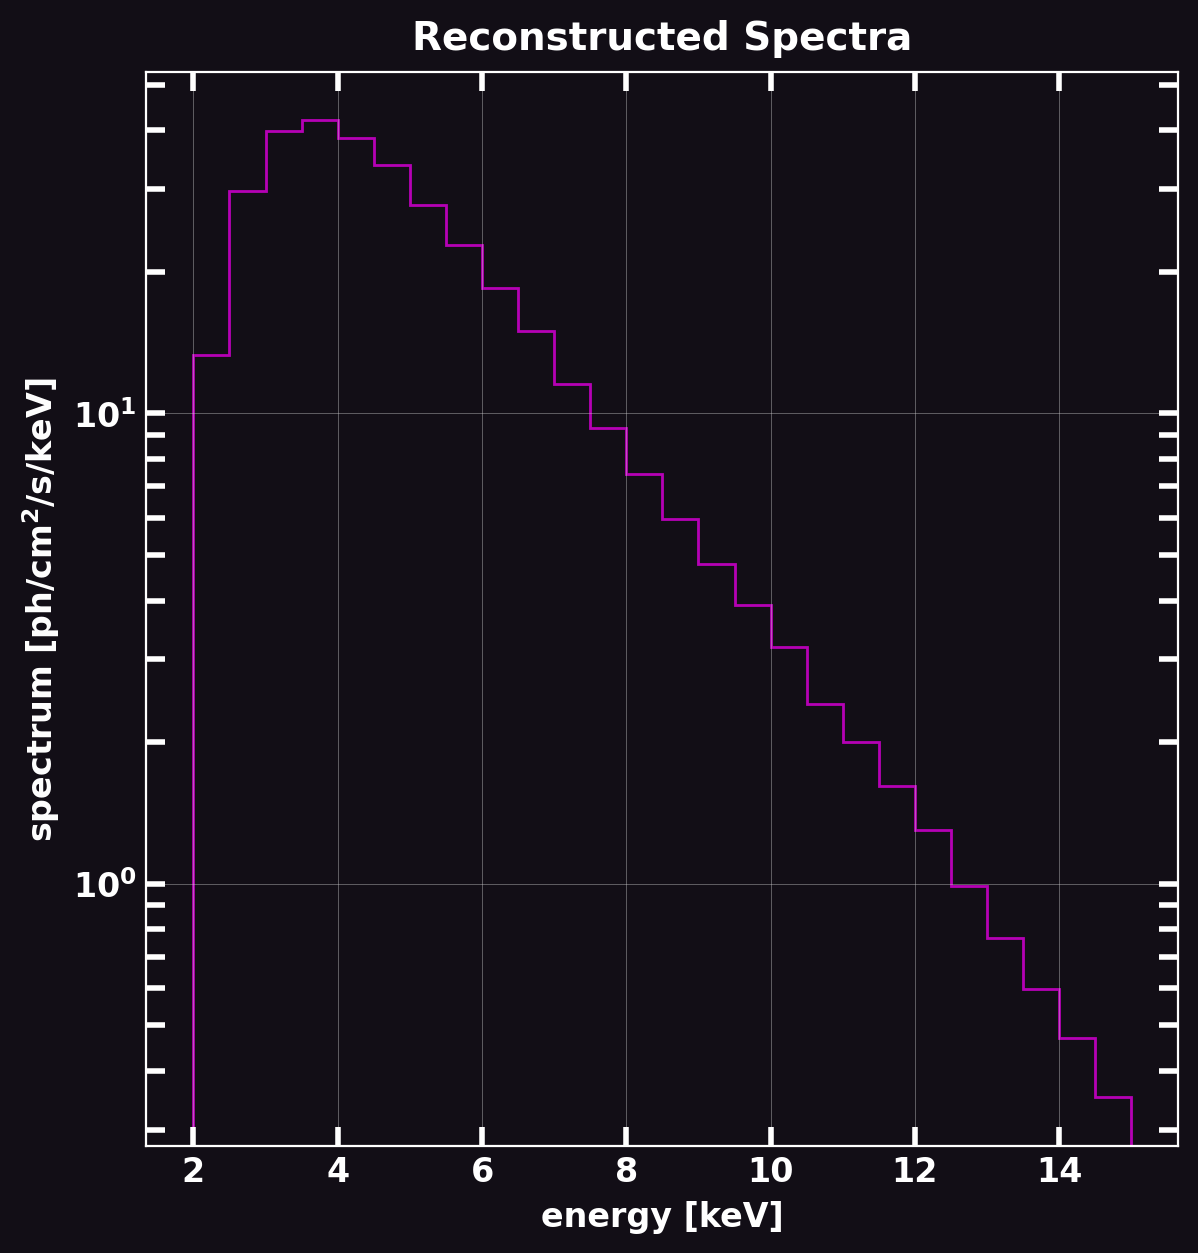

In [18]:
ebins, spectra = compute_spectra(out_logs)

ds.plot(
    ds.map4plot(
        arrs=list(spectra[:, idx] for idx in range(spectra.shape[-1])) + list(true_spectr.values()),
        title='Reconstructed Spectra',
        x=ebins,
        xlabel='energy [keV]',
        ylabel='spectrum [ph/cm$^{2}$/s/keV]',
        labels=srcIDs,
        style='stairs',
        color=('m', 'DeepSkyBlue', 'LawnGreen', 'Orange'),
        yscale='log',
    ),
    save_to=f'{OUT_RESULTS_PATH}/spectrs.png',
)